# 지도학습 - 분류 둘러보기

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

sklearn.__version__

'1.8.0'

In [2]:
# Mac 기준 한글 폰트 설정
plt.rcParams["font.family"] = "AppleGothic"
# 마이너스 부호 깨짐 문제 방지
plt.rcParams["axes.unicode_minus"] = False

# 생선 이진 분류 - 도미냐? 빙어냐?
<table>
    <tr>
        <td><img src="https://d.pr/i/FaQ4RH+" width="300"></td>
        <td><img src="https://d.pr/i/NmXwPX+" width="300"></td>
    </tr>
</table>

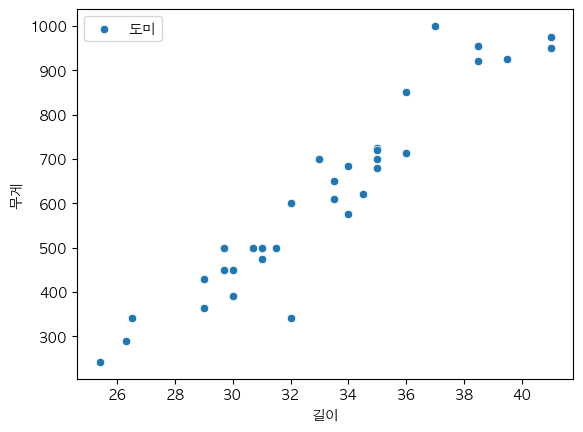

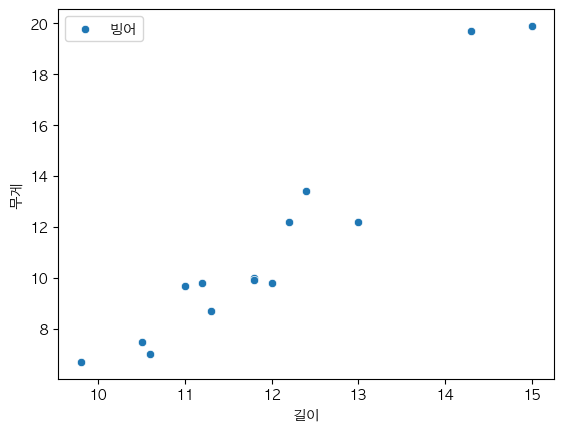

In [3]:
# 도미 데이터
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

# 산포도 시각화
sns.scatterplot(x=bream_length, y=bream_weight, label="도미")
plt.xlabel("길이")
plt.ylabel("무게")
plt.show()

# 빙어 데이터 
smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

# 산포도 시각화
sns.scatterplot(x=smelt_length, y=smelt_weight, label="빙어")
plt.xlabel("길이")
plt.ylabel("무게")
plt.show()

## 최근접이웃분류모델을 이용한 분류
- 데이터 포인트 간의 거리 기반으로 분류를 수행하는 모델

In [4]:
# 학습을 위한 데이터 포맷
length = bream_length + smelt_length
weight = bream_weight + smelt_weight
print(len(bream_length), len(smelt_length)) # 도미 데이터 35개, 빙어 데이터 14개
print(len(length), len(weight)) # 길이 데이터 49개, 무게 데이터 49개

35 14
49 49


In [5]:
# 입력(X) : 길이, 무게 -> 특성(Feature)
fish_data = np.array([[l, w] for l, w in zip(length, weight)])
fish_data

array([[  25.4,  242. ],
       [  26.3,  290. ],
       [  26.5,  340. ],
       [  29. ,  363. ],
       [  29. ,  430. ],
       [  29.7,  450. ],
       [  29.7,  500. ],
       [  30. ,  390. ],
       [  30. ,  450. ],
       [  30.7,  500. ],
       [  31. ,  475. ],
       [  31. ,  500. ],
       [  31.5,  500. ],
       [  32. ,  340. ],
       [  32. ,  600. ],
       [  32. ,  600. ],
       [  33. ,  700. ],
       [  33. ,  700. ],
       [  33.5,  610. ],
       [  33.5,  650. ],
       [  34. ,  575. ],
       [  34. ,  685. ],
       [  34.5,  620. ],
       [  35. ,  680. ],
       [  35. ,  700. ],
       [  35. ,  725. ],
       [  35. ,  720. ],
       [  36. ,  714. ],
       [  36. ,  850. ],
       [  37. , 1000. ],
       [  38.5,  920. ],
       [  38.5,  955. ],
       [  39.5,  925. ],
       [  41. ,  975. ],
       [  41. ,  950. ],
       [   9.8,    6.7],
       [  10.5,    7.5],
       [  10.6,    7. ],
       [  11. ,    9.7],
       [  11.2,    9.8],


In [6]:
# 출력(y): 도미(1), 빙어(0) -> 라벨(label)
fish_target = np.array([1] * 35 + [0] * 14)
fish_target

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0])

In [7]:
# 문제, 정답 크기 비교
# X -> (샘플 수, 특성 수)
# y -> (샘플 수)
print(fish_data.shape)
print(fish_target.shape)

(49, 2)
(49,)


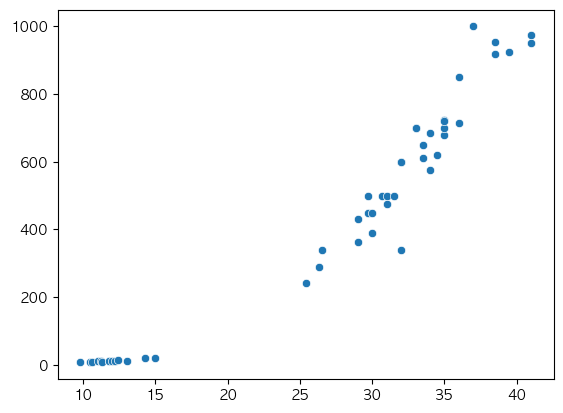

In [8]:
# 시각화
sns.scatterplot(x=fish_data[:,0], y=fish_data[:,1])
plt.show()

## k-최근접 이웃 알고리즘 작동 원리
최근접 이웃 알고리즘(K-Nearest Neighbors, KNN)은 거리를 구하는 방법으로 가장 일반적으로 사용 되는 방법은
**유클리드 거리(Euclidean distance)** 이다. 
유클리드 거리는 "두 점 사이의 직선 거리"를 구하는 가장 간단한 방법이다.

In [9]:
# 모델 준비: scikit-learn의 KNN 분류기 클래스를 가져온다.
from sklearn.neighbors import KNeighborsClassifier

# 기본 설정의 KNN 모델 생성
# 기본 값으로 n_neighbors=5 이다 
# => 가장 가까운 이웃 5개를 보고 다수결로 분류한다.
kn_clf = KNeighborsClassifier()
kn_clf

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [10]:
# 모델 학습
# fit(X, y) : 입력 데이터(X)와 정답(y)를 모델에 전달한다.
# KNN은 복잡한 수식을 학습하기 보다는 학습 데이터를 내부에 저장해두고 예측 시 거리를 계산하는 방식
kn_clf.fit(fish_data, fish_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [11]:
# 모델 성능 평가
# score(X, y) : 주어진 데이터에 대한 정확도를 계산한다.
# 지금은 학습에 사용한 데이터로 다시 평가했기 때문에 점수가 높게 나올 수 밖에 없음
kn_clf.score(fish_data, fish_target)

1.0

In [12]:
# 모델 예측
# predict() : 새로운 입력에 대해 클래스를 예측한다.
kn_clf.predict([[40, 500], [10, 10]])   # 도미, 빙어 예측 성공

array([1, 0])

[[ 8.5         9.          9.3        10.3        26.57066051]] [[12 11  9  6 10]]


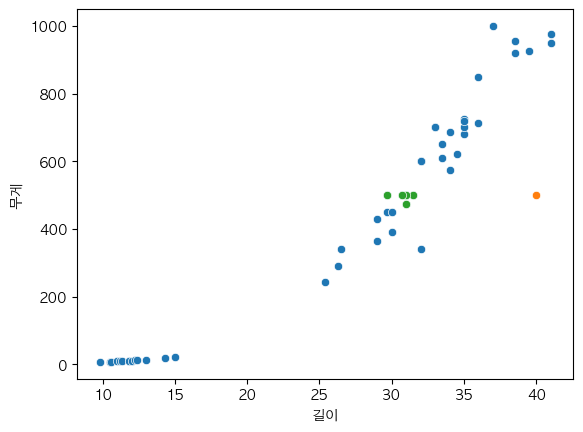

In [13]:
# 이웃 확인
# distance : 각 이웃까지의 거리
# index : 원본 학습 데이터에서 그 이웃들이 몇 번째 샘플인지
distance, index = kn_clf.kneighbors([[40, 500]])
print(distance, index)

# 최근접 이웃 target 확인
# 5개의 이웃 모두 도미이기 때문에 다수결로 도미로 판단함
fish_target[index]

# 시각화
sns.scatterplot(x=fish_data[:,0], y=fish_data[:,1]) # 학습 데이터
sns.scatterplot(x=[40], y=[500])                    # 문제
index = index.squeeze() # 2차원 -> 1차원
sns.scatterplot(x=fish_data[index,0], y=fish_data[index,1]) # 최근접 이웃

plt.xlabel("길이")
plt.ylabel("무게")
plt.show()

## 학습/테스트 세트 분리
위에서는 KNN의 동작 원리를 확인해 보았다. 이제부터는 이 모델을 믿어도 되는지를 확인한다.
- 학습용 데이터(train set): 모델이 공부하는 데이터
- 테스트용 데이터(test set): 학습에 쓰지 않고 마지막에 실력을 검사하는 데이터

In [14]:
from sklearn.model_selection import train_test_split

# train_test_split : 전체 데이터를 학습용과 테스트용으로 나눈다.
(X_train, X_test, y_train, y_test) = train_test_split(
    fish_data, 
    fish_target, 
    stratify=fish_target,       # 도미와 빙어의 비율이 train/test에서 비슷하게 유지 되도록 분리
    test_size=0.2,              # 전체의 20%를 테스트 데이터로 사용
    random_state=42             # 실행할 때마다 같은 방식으로 섞이도록 고정
    )

# 분리 결과 확인
print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

X_train: (39, 2)
y_train: (39,)
X_test: (10, 2)
y_test: (10,)


In [15]:
# 다시 모델 준비
kn_clf = KNeighborsClassifier()

# 학습
kn_clf.fit(X_train, y_train)                # 학습용 데이터 사용

# 성능 평가
print(kn_clf.score(X_test, y_test))        # 테스트 데이터 사용 (모델이 처음 보는 데이터를 잘 맞추는지)

# 예측 (테스트 데이터 전체에 대한 예측, 실제 정답과 비교)
print(kn_clf.predict(X_test))
print(y_test)

1.0
[1 0 1 1 0 1 1 1 0 1]
[1 0 1 1 0 1 1 1 0 1]


## 수상한 도미
도미 (길이 25, 무게 150)의 문제

In [16]:
# 실제 데이터는 도미이지만 빙어로 판단 되는 결과
kn_clf.predict([[25, 150]])

array([0])

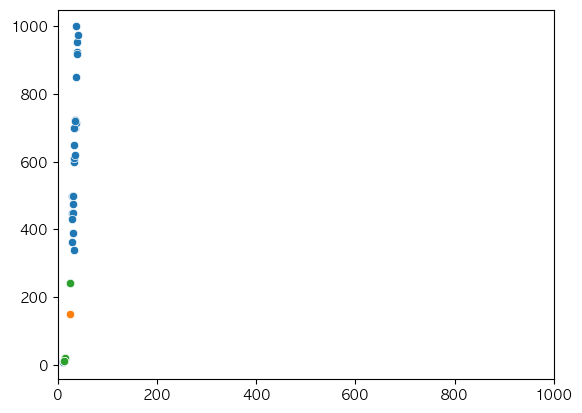

In [17]:
# 시각화
sns.scatterplot(x=X_train[:, 0], y=X_train[: ,1])         # 학습 데이터
sns.scatterplot(x=[25], y=[150])                            # 문제 (예측)
distance, index = kn_clf.kneighbors([[25, 150]])
sns.scatterplot(x=X_train[index.squeeze(), 0], y=X_train[index.squeeze(), 1]) # 최근접 이웃 표시

# 길이(10~40)보다 무게(0~1000)의 스케일이 훨씬 크기 때문에 거리 계산에서 무게가 큰 영향력을 갖게 되었음
plt.xlim(0, 1000)
plt.show()

## 표준 점수 스케일링
서로 다른 속성의 값의 범위를 맞추기 위한 전처리 기법. 

###  표준점수로 환산하기
표준점수(또는 Z-점수)는 데이터가 평균에서 얼마나 떨어져 있는지를 표준편차 단위로 나타낸 값이다.

$Z = \frac{X - \mu}{\sigma}$

-   $X$는 데이터 값
-   $\mu$는 데이터의 평균
-   $\sigma$는 데이터의 표준편차

특성값에서 평균을 빼고, 표준편차로 나누기.

In [18]:
from sklearn.preprocessing import StandardScaler

# 다시 학습/테스트 분리
(X_train, X_test, y_train, y_test) = train_test_split(
    fish_data, 
    fish_target, 
    stratify=fish_target,       # 도미와 빙어의 비율이 train/test에서 비슷하게 유지 되도록 분리
    test_size=0.2,              # 전체의 20%를 테스트 데이터로 사용
    random_state=42             # 실행할 때마다 같은 방식으로 섞이도록 고정
    )

# 스케일러 준비 : 특성별로 평균과 표준편차를 구한 뒤 Z-score 형태로 변환
scaler = StandardScaler()

# 학습 데이터로 기준 만들기 + 변환
X_train_scaled = scaler.fit_transform(X_train)

# 테스트 데이터는 학습 데이터에서 구한 기준을 그대로 사용해서 변환
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled)
print(X_test_scaled)


[[-1.58299969 -1.3623164 ]
 [-0.18349562 -0.64945483]
 [-1.53337188 -1.35864973]
 [-1.49366964 -1.35162194]
 [ 1.11675283  1.52915767]
 [ 0.76935821  0.82637944]
 [ 0.47159139  0.44443476]
 [ 0.47159139 -0.35001019]
 [ 0.76935821  0.74999051]
 [ 0.47159139  0.44443476]
 [ 0.24330349 -0.01389887]
 [ 0.24330349  0.13887901]
 [ 0.6204748   0.59721263]
 [ 0.6204748   0.47499033]
 [ 0.27308017 -0.01389887]
 [ 1.21600844  1.43749094]
 [-1.59292525 -1.35895528]
 [-1.51352076 -1.35895528]
 [ 0.86861382  1.20832413]
 [ 0.17382456 -0.27973237]
 [ 0.3425591   0.13887901]
 [ 0.42196358  0.13887901]
 [-1.28523287 -1.32870526]
 [ 0.37233578  0.06249007]
 [ 1.11675283  1.42221316]
 [-1.7318831  -1.36842751]
 [ 0.57084699  0.74999051]
 [-1.66240417 -1.36598306]
 [ 0.86861382  0.79276831]
 [-1.65247861 -1.36751084]
 [ 0.96786942  1.66665776]
 [ 0.27308017 -0.19723232]
 [ 0.57084699  0.74999051]
 [ 0.17382456 -0.07501002]
 [-1.41426516 -1.35162194]
 [ 1.36489185  1.59026882]
 [-1.21575394 -1.32809415]
 

In [19]:
# 스케일링 된 데이터로 모델 학습 
kn_clf = KNeighborsClassifier()
kn_clf.fit(X_train_scaled, y_train)
kn_clf.score(X_test_scaled, y_test)

1.0

In [20]:
# 스케일링 데이터로 학습한 모델을 통해 수상한 도미 예측하기
# 새 샘플도 반드시 같은 scaler로 변환해서 에측해야 한다.
q = scaler.transform([[25, 150]])

# 무게와 길이 값 스케일링 후 도미로 판단 되는 모습 확인
kn_clf.predict(q)

array([1])

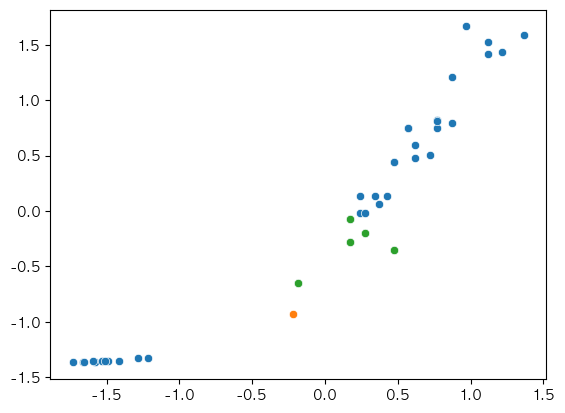

In [21]:
# 스케일링 후 시각화
sns.scatterplot(x=X_train_scaled[:, 0], y=X_train_scaled[: ,1])         # 학습 데이터
sns.scatterplot(x=q[:,0], y=q[:,1])                                     # 문제 (예측)
distance, index = kn_clf.kneighbors(q)
sns.scatterplot(x=X_train_scaled[index.squeeze(), 0], y=X_train_scaled[index.squeeze(), 1]) # 최근접 이웃 표시

plt.show()

# 생선 다중분류

| Fish      | Korean Name | Image | Avg Size |
|-----------|-------------|-------|----------|
| Bream     | 도미        | <img src="https://d.pr/i/FaQ4RH+" alt="Bream" width="300px"> | 평균 길이 50~60cm, 최대 1m |
| Roach     | 붕어        | <img src="https://d.pr/i/C8jz9h+" alt="Roach" width="300px"> | 평균 길이 20~30cm *(일반적인 붕어 기준)* |
| Whitefish | 흰물고기    | <img src="https://d.pr/i/5z0jBB+" alt="Whitefish" width="300px"> | 평균 길이 30~50cm *(종류에 따라 다름)* |
| Parkki    | 파키        | <img src="https://d.pr/i/CcYfbX+" alt="Parkki" width="300px"> | 평균 길이 15~20cm *(일반적인 파키 기준)* |
| Perch     | 농어        | <img src="https://d.pr/i/JvhJwh+" alt="Perch" width="300px"> | 평균 길이 50~60cm, 최대 1m |
| Pike      | 강꼬치고기  | <img src="https://d.pr/i/NNWlsh+" alt="Pike" width="300px"> | 평균 길이 40~55cm, 최대 1m 이상<br>*(북방강꼬치고기 기준)* |
| Smelt     | 빙어        | <img src="https://d.pr/i/NmXwPX+" alt="Smelt" width="300px"> | 평균 길이 10~15cm *(빙어 기준)* |


**참고 및 설명**
- 도미(Bream)는 대표적으로 참돔을 기준으로 하였으며, 평균 길이 50~60cm, 최대 1m까지 자랍니다.
- 농어(Perch)는 실제로는 Perch(배스)와 농어(Seabass)가 다르나, 표 내 농어는 평균 50~60cm, 최대 1m 이상까지 자랍니다.
- 붕어(Roach), 파키(Parkki), 빙어(Smelt) 등은 한국 내 일반적인 평균 크기를 참고하였습니다.
- 흰물고기(Whitefish), 강꼬치고기(Pike)는 여러 종류가 있으나, 대표적인 종의 평균 크기를 기재했습니다.

In [22]:
# 데이터 로드
fish_df = pd.read_csv('data/fish.csv')
fish_df

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [23]:
fish_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    str    
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), str(1)
memory usage: 7.6 KB


In [24]:
fish_df.describe()

,Weight,Length,Diagonal,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,28.415723,31.227044,8.970994,4.417486
std,357.978317,10.716328,11.610246,4.286208,1.685804
min,0.000000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,63.400000,68.000000,18.957000,8.142000


In [25]:
# 각 클래스 개수 확인
fish_df['Species'].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [26]:
# input(X), label(Y) 분리
# 이진 분류 예제에서는 Feature가 l, w 2개였으나 특성이 여러개로 증가

# dataframe 이나 numpy로 데이터 관리 모두 가능
fish_input = fish_df[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
fish_target = fish_df['Species'].to_numpy()

# shape 확인
# input의 shape는 (샘플 수, 특성 수)
print(fish_input.shape, fish_target.shape)

(159, 5) (159,)


In [27]:
# 학습/테스트 분리
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    fish_input,
    fish_target,
    stratify=fish_target,
    random_state=42,
    test_size=0.25
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(119, 5) (119,)
(40, 5) (40,)


In [28]:
# 표준점수 스케일링
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# 학습 데이터 기준 평균/표준편차 계산 + 표준점수 변환
X_train_scaled = scaler.fit_transform(X_train)
# 학습 데이터 기준으로 표준 점수 변환
X_test_scaled = scaler.transform(X_test)

In [29]:
# 모델 학습
from sklearn.neighbors import KNeighborsClassifier

kn_clf = KNeighborsClassifier()
kn_clf.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [30]:
# 평가
print(kn_clf.score(X_train_scaled, y_train))
print(kn_clf.score(X_test_scaled, y_test))

0.8571428571428571
0.775


In [31]:
# 모델 학습 현황 - 메모리 상주 데이터
print(kn_clf._fit_X)
print(kn_clf._y)
print(kn_clf.classes_)

[[-7.56288032e-01 -6.60656767e-01 -6.23574459e-01 -7.80151591e-01
  -4.50436444e-01]
 [-4.59910572e-01 -1.24845300e-01 -2.44146026e-01 -4.29348704e-01
   3.51691877e-02]
 [ 7.35688553e-02  2.12851003e-02  2.16588499e-01  7.95412076e-01
   3.74817965e-01]
 [ 1.54063728e+00  1.04419790e+00  1.23743166e+00  2.29283234e+00
   1.34130358e+00]
 [-8.74839016e-01 -7.58077034e-01 -8.22322686e-01 -8.06729366e-01
  -5.69714299e-01]
 [-6.16990626e-01 -3.09943807e-01 -4.15792222e-01 -6.00632966e-01
  -1.60556561e-01]
 [-9.93390000e-01 -1.10878999e+00 -1.18368310e+00 -1.06882893e+00
  -9.36700077e-01]
 [ 8.73787997e-01  4.10966168e-01  6.23118963e-01  1.38724215e+00
   4.12802638e-01]
 [-4.00635080e-01 -2.22265567e-01 -2.08009985e-01 -2.24652384e-01
  -1.54873814e-01]
 [-4.83620769e-01 -3.29427860e-01 -1.44771913e-01  5.76145440e-01
  -2.91558819e-01]
 [-8.60020143e-01 -7.58077034e-01 -8.22322686e-01 -7.53336516e-01
  -7.17764796e-01]
 [ 1.52581841e+00  9.46777635e-01  1.12902354e+00  2.12261594e+00

In [32]:
# 모델 예측
print(kn_clf.predict(X_test_scaled[:5]))        # 예측
print(y_test[:5])                               # 정답

['Perch' 'Perch' 'Perch' 'Parkki' 'Parkki']
['Roach' 'Perch' 'Perch' 'Parkki' 'Parkki']


In [33]:
# 이웃을 통한 라벨 예측 과정
# predict_proba : 각 클래스에대한 확률 분포를 반환
proba = kn_clf.predict_proba(X_test_scaled[:5])
print(proba)

[[0.  0.  0.8 0.  0.2 0.  0. ]
 [0.  0.  0.6 0.  0.4 0.  0. ]
 [0.  0.  0.6 0.  0.4 0.  0. ]
 [0.  0.6 0.  0.  0.4 0.  0. ]
 [0.  0.4 0.2 0.  0.4 0.  0. ]]


In [34]:
# 틀린 첫 번째의 이웃 찾기
distance, index = kn_clf.kneighbors(X_test_scaled[:1])
print(index)
print(X_train_scaled[index[0]])
print(y_train[index[0]])

[[100  10 117  69  48]]
[[-0.87483902 -0.77756109 -0.76811862 -0.69396367 -0.66500498]
 [-0.86002014 -0.75807703 -0.82232269 -0.75333652 -0.7177648 ]
 [-0.84520127 -0.66065677 -0.73198258 -0.70765597 -0.65794641]
 [-0.81556352 -0.66065677 -0.73198258 -0.70765597 -0.58765981]
 [-0.84520127 -0.66065677 -0.73198258 -0.8191877  -0.58765981]]
['Roach' 'Perch' 'Perch' 'Perch' 'Perch']


## 붓꽃 다중 분류

붓꽃은 세포핵을 둘러싼 꽃받침(sepal)과 꽃잎(petal)으로 구성되어 있으며, 이러한 특징을 기반으로 붓꽃의 품종을 식별할 수 있습니다.

- Setosa (세토사): Setosa는 붓꽃 중에서 가장 작은 꽃잎과 꽃받침을 가지고 있습니다.
꽃잎과 꽃받침이 비교적 짧고 뾰족한 모습을 갖고 있으며, 주로 흰색 또는 연한 분홍색을 띠고 있습니다.

- Versicolor (버시컬러): Versicolor는 Setosa보다 크고 긴 꽃잎과 꽃받침을 가지고 있습니다.
꽃잎의 색은 보통 연한 보라색이며, 중간 크기의 붓꽃입니다.

- Virginica (버지니카): Virginica는 붓꽃 중에서 가장 크고 긴 꽃잎과 꽃받침을 가지고 있습니다.
꽃잎의 색은 주로 짙은 보라색이며, 다른 품종들에 비해 상대적으로 더 큰 크기를 갖고 있습니다.

![](https://d.pr/i/4egoon+)

In [35]:
# 데이터 로드
from sklearn.datasets import load_iris

iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [36]:
# 입력 데이터
print(iris.feature_names)
print(iris.data)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3

In [37]:
# 라벨 데이터
print(iris.target_names)
print(iris.target)

['setosa' 'versicolor' 'virginica']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [38]:
# 최근접 이웃모델을 통한 다중 분류 구현

# 입력/라벨 데이터 구분
# 학습/평가 데이터 구분
# 모델 학습/평가/예측